In [39]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/aps-failure-at-scania-trucks-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Nayan\.cache\kagglehub\datasets\uciml\aps-failure-at-scania-trucks-data-set\versions\3


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
test_set = pd.read_csv(r"C:\Users\Nayan\.cache\kagglehub\datasets\uciml\aps-failure-at-scania-trucks-data-set\versions\3\aps_failure_test_set.csv")
test_processed = pd.read_csv(r"C:\Users\Nayan\.cache\kagglehub\datasets\uciml\aps-failure-at-scania-trucks-data-set\versions\3\aps_failure_test_set_processed_8bit.csv")

In [42]:
train_set = pd.read_csv(r"C:\Users\Nayan\.cache\kagglehub\datasets\uciml\aps-failure-at-scania-trucks-data-set\versions\3\aps_failure_training_set.csv")
train_processed = pd.read_csv(r"C:\Users\Nayan\.cache\kagglehub\datasets\uciml\aps-failure-at-scania-trucks-data-set\versions\3\aps_failure_training_set_processed_8bit.csv")

In [43]:
train_set.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0


In [44]:
test_set.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,60,0,20,12,0,0,0,0,0,...,1098,138,412,654,78,88,0,0,0,0
1,neg,82,0,68,40,0,0,0,0,0,...,1068,276,1620,116,86,462,0,0,0,0
2,neg,66002,2,212,112,0,0,0,0,0,...,495076,380368,440134,269556,1315022,153680,516,0,0,0
3,neg,59816,na,1010,936,0,0,0,0,0,...,540820,243270,483302,485332,431376,210074,281662,3232,0,0
4,neg,1814,na,156,140,0,0,0,0,0,...,7646,4144,18466,49782,3176,482,76,0,0,0


In [45]:
train_set.shape

(60000, 171)

In [46]:
test_set.shape

(16000, 171)

In [47]:
train_set['class'].value_counts()

class
neg    59000
pos     1000
Name: count, dtype: int64

In [48]:
train_set.isnull().sum()

class     0
aa_000    0
ab_000    0
ac_000    0
ad_000    0
         ..
ee_007    0
ee_008    0
ee_009    0
ef_000    0
eg_000    0
Length: 171, dtype: int64

In [49]:
train_set.duplicated().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='class'>

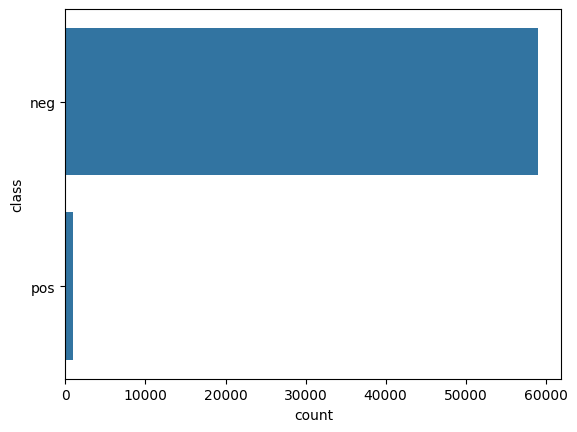

In [50]:
sns.countplot(train_set['class'])

<Axes: xlabel='count', ylabel='class'>

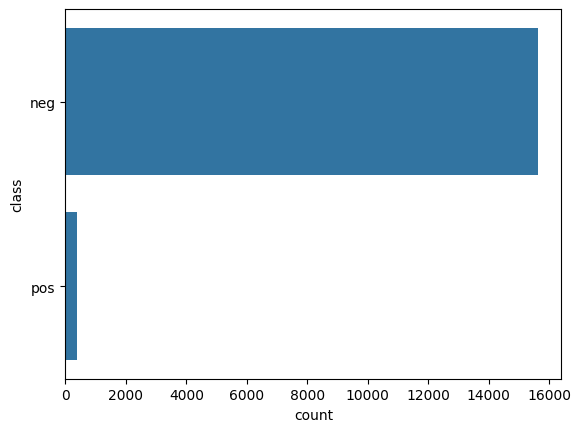

In [51]:
sns.countplot(test_set['class'])

In [52]:
train_set[train_set['class']=='pos'].shape[0]/train_set.shape[0]*100

1.6666666666666667

In [53]:
train_set[train_set['class']=='neg'].shape[0]/train_set.shape[0]*100

98.33333333333333

In [54]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: int64(1), object(170)
memory usage: 78.3+ MB


In [55]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Columns: 171 entries, class to eg_000
dtypes: int64(1), object(170)
memory usage: 20.9+ MB


In [56]:
train_set.columns

Index(['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000',
       'ag_000', 'ag_001', 'ag_002',
       ...
       'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_006', 'ee_007', 'ee_008',
       'ee_009', 'ef_000', 'eg_000'],
      dtype='object', length=171)

In [57]:
train_set.head(10)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0
5,neg,38312,na,2130706432,218,0,0,0,0,0,...,388574,288278,900430,300412,1534,338,856,0,0,0
6,neg,14,0,6,na,0,0,0,0,0,...,168,48,60,28,0,0,0,0,0,0
7,neg,102960,na,2130706432,116,0,0,0,0,0,...,715518,384948,915978,1052166,1108672,341532,129504,7832,0,0
8,neg,78696,na,0,na,0,0,0,0,0,...,699290,362510,1190028,1012704,160090,63216,41202,4,0,0
9,pos,153204,0,182,na,0,0,0,0,0,...,129862,26872,34044,22472,34362,0,0,0,0,0


In [58]:
train_set = train_set.replace('na', np.nan)
train_set.head(10)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,NaN,0,NaN,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,NaN,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,NaN,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0
5,neg,38312,NaN,2130706432,218,0,0,0,0,0,...,388574,288278,900430,300412,1534,338,856,0,0,0
6,neg,14,0,6,NaN,0,0,0,0,0,...,168,48,60,28,0,0,0,0,0,0
7,neg,102960,NaN,2130706432,116,0,0,0,0,0,...,715518,384948,915978,1052166,1108672,341532,129504,7832,0,0
8,neg,78696,NaN,0,NaN,0,0,0,0,0,...,699290,362510,1190028,1012704,160090,63216,41202,4,0,0
9,pos,153204,0,182,NaN,0,0,0,0,0,...,129862,26872,34044,22472,34362,0,0,0,0,0


In [59]:
test_set.head(10)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,60,0,20,12,0,0,0,0,0,...,1098,138,412,654,78,88,0,0,0,0
1,neg,82,0,68,40,0,0,0,0,0,...,1068,276,1620,116,86,462,0,0,0,0
2,neg,66002,2,212,112,0,0,0,0,0,...,495076,380368,440134,269556,1315022,153680,516,0,0,0
3,neg,59816,na,1010,936,0,0,0,0,0,...,540820,243270,483302,485332,431376,210074,281662,3232,0,0
4,neg,1814,na,156,140,0,0,0,0,0,...,7646,4144,18466,49782,3176,482,76,0,0,0
5,neg,174,na,26,24,0,0,na,na,na,...,na,na,na,na,na,na,na,na,0,0
6,neg,40202,na,640,606,0,0,0,0,0,...,526218,239734,439556,374248,169096,53658,41054,320,0,0
7,neg,120278,na,2130706432,256,0,0,0,0,0,...,1006722,459658,876356,689532,568540,500624,1006628,34820,0,0
8,neg,14592,0,2130706438,162,0,0,0,0,0,...,105024,57398,49152,38256,243268,145144,0,0,0,0
9,neg,28338,na,2130706432,238,0,0,0,0,0,...,357006,150056,264776,239282,140548,74750,32958,84,0,0


In [60]:
test_set = test_set.replace('na',np.nan)

In [61]:
test_set.head(10)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,60,0,20,12,0,0,0,0,0,...,1098,138,412,654,78,88,0,0,0,0
1,neg,82,0,68,40,0,0,0,0,0,...,1068,276,1620,116,86,462,0,0,0,0
2,neg,66002,2,212,112,0,0,0,0,0,...,495076,380368,440134,269556,1315022,153680,516,0,0,0
3,neg,59816,NaN,1010,936,0,0,0,0,0,...,540820,243270,483302,485332,431376,210074,281662,3232,0,0
4,neg,1814,NaN,156,140,0,0,0,0,0,...,7646,4144,18466,49782,3176,482,76,0,0,0
5,neg,174,NaN,26,24,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
6,neg,40202,NaN,640,606,0,0,0,0,0,...,526218,239734,439556,374248,169096,53658,41054,320,0,0
7,neg,120278,NaN,2130706432,256,0,0,0,0,0,...,1006722,459658,876356,689532,568540,500624,1006628,34820,0,0
8,neg,14592,0,2130706438,162,0,0,0,0,0,...,105024,57398,49152,38256,243268,145144,0,0,0,0
9,neg,28338,NaN,2130706432,238,0,0,0,0,0,...,357006,150056,264776,239282,140548,74750,32958,84,0,0


In [80]:
cat_col = train_set.select_dtypes(include='object').columns
cat_col

Index(['class', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001',
       'ag_002', 'ag_003', 'ag_004',
       ...
       'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_006', 'ee_007', 'ee_008',
       'ee_009', 'ef_000', 'eg_000'],
      dtype='object', length=162)

In [82]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 163 entries, class to eg_000
dtypes: int64(1), object(162)
memory usage: 74.6+ MB


In [91]:
for i in cat_col:
    if i != 'class':
        train_set[i] = pd.to_numeric(train_set[i], errors='coerce')

In [85]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 163 entries, class to eg_000
dtypes: int64(1), object(162)
memory usage: 74.6+ MB


In [86]:
train_set.describe()

,aa_000
count,6.000000e+04
mean,5.933650e+04
std,1.454301e+05
min,0.000000e+00
25%,8.340000e+02
50%,3.077600e+04
75%,4.866800e+04
max,2.746564e+06


In [87]:
num_col = [i for i in train_set.columns if train_set[i].dtype!='0']
len(num_col)

163

In [88]:
train_set.info(),train_set.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 163 entries, class to eg_000
dtypes: int64(1), object(162)
memory usage: 74.6+ MB


(None, (60000, 163))

In [89]:
missing_value = train_set.isna().sum()/train_set.shape[0]*100
missing_value = missing_value.to_frame().sort_values(by=0, ascending=False)

In [90]:
list(missing_value[missing_value[0]>60].index)

[]

In [71]:
train_set.drop(['br_000',
 'bq_000',
 'bp_000',
 'bo_000',
 'ab_000',
 'cr_000',
 'bn_000',
 'bm_000'],
               axis=1, inplace=True)

In [72]:
train_set.shape

(60000, 163)

In [73]:
missing_value = train_set.isnull().sum().sum()
cell = np.prod(train_set.shape)
missing_value/cell*100

np.float64(4.925766871165644)

In [74]:
train_set.describe()

,aa_000
count,6.000000e+04
mean,5.933650e+04
std,1.454301e+05
min,0.000000e+00
25%,8.340000e+02
50%,3.077600e+04
75%,4.866800e+04
max,2.746564e+06
